# Final Project: Drug Use Analysis Among  by Age

**Course:** SEIS 631 – Data Preparation and Analysis  
**Professor:** Dr. John  
**Student:** Debisa Woyessa  

# Project Topic
Project Topic:  Drug Use by Age  
Assignment: Choose Your Own Hypothesis – EDA Check-in


# Overview
 This project presents an exploratory data analysis (EDA) of drug use using the FiveThirtyEight drug-use-by-age dataset. The purpose of this analysis is to identify patterns in substance use across different age groups, compare substances such as alcohol and marijuana, and explore relationships between age and usage levels.

The findings from this analysis will help provide meaningful insights and support potential policy or public health recommendations.

 Dataset: FiveThirtyEight – drug-use-by-age.csv

This dataset is well-suited for this project because it directly aligns with the topic of youth drug use by age. It is clean, structured, and easy to analyze using Python in Jupyter Notebook.

The dataset includes:
-Age groups (including youth ages 12–17)Young Adults (18–34) 
Older Adults (35+) 

-Multiple substance-use variables (alcohol, marijuana, cocaine, etc.)

It is also appropriate for:
-Exploratory Data Analysis (EDA)
-Data visualization (graphs and histograms)
-Statistical testing (permutation and bootstrap)

Final Decision:
This dataset was selected because it is manageable, relevant, and supports meaningful analysis of substance use patterns across age groups.


Research Question
How does marijuana use differ across age groups, especially among youth (12–17), young adults (18–
35), and older adults (35+)?


Hypotheses:

H₀ (Null Hypothesis): The mean marijuana use is the same across all age groups.
H₁ (Alternative Hypothesis): At least one age group has a different mean marijuana use.


I use the following Python libraries:
-pandas for data manipulation
-numpy for numerical operations
-matplotlib for data visualization


1.Import Libraries Question: What Python libraries do we need?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('drug-use-by-age.csv')


2.Load Dataset Question: How do we load the dataset?


In [2]:
df = pd.read_csv('drug-use-by-age.csv')
df.head()

for col in df.columns:
    if col != 'age':
        df[col] = pd.to_numeric(df[col], errors='coerce')
 


3.Check Variables Question: What variables are included in the dataset?


In [3]:
df.head()
df.columns

Index(['age', 'n', 'alcohol_use', 'alcohol_frequency', 'marijuana_use',
       'marijuana_frequency', 'cocaine_use', 'cocaine_frequency', 'crack_use',
       'crack_frequency', 'heroin_use', 'heroin_frequency', 'hallucinogen_use',
       'hallucinogen_frequency', 'inhalant_use', 'inhalant_frequency',
       'pain_releiver_use', 'pain_releiver_frequency', 'oxycontin_use',
       'oxycontin_frequency', 'tranquilizer_use', 'tranquilizer_frequency',
       'stimulant_use', 'stimulant_frequency', 'meth_use', 'meth_frequency',
       'sedative_use', 'sedative_frequency'],
      dtype='str')

In [4]:
df.isnull().sum()

age                        0
n                          0
alcohol_use                0
alcohol_frequency          0
marijuana_use              0
marijuana_frequency        0
cocaine_use                0
cocaine_frequency          1
crack_use                  0
crack_frequency            3
heroin_use                 0
heroin_frequency           1
hallucinogen_use           0
hallucinogen_frequency     0
inhalant_use               0
inhalant_frequency         1
pain_releiver_use          0
pain_releiver_frequency    0
oxycontin_use              0
oxycontin_frequency        1
tranquilizer_use           0
tranquilizer_frequency     0
stimulant_use              0
stimulant_frequency        0
meth_use                   0
meth_frequency             2
sedative_use               0
sedative_frequency         0
dtype: int64

5.Clean Missing Values

In [5]:

df = df.replace("-", np.nan)

for col in df.columns:
    if col != "age":
        df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()


,age,n,alcohol_use,alcohol_frequency,marijuana_use,marijuana_frequency,cocaine_use,cocaine_frequency,crack_use,crack_frequency,...,oxycontin_use,oxycontin_frequency,tranquilizer_use,tranquilizer_frequency,stimulant_use,stimulant_frequency,meth_use,meth_frequency,sedative_use,sedative_frequency
0,12,2798,3.9,3.0,1.1,4.0,0.1,5.0,0.0,NaN,...,0.1,24.5,0.2,52.0,0.2,2.0,0.0,NaN,0.2,13.0
1,13,2757,8.5,6.0,3.4,15.0,0.1,1.0,0.0,3.0,...,0.1,41.0,0.3,25.5,0.3,4.0,0.1,5.0,0.1,19.0
2,14,2792,18.1,5.0,8.7,24.0,0.1,5.5,0.0,NaN,...,0.4,4.5,0.9,5.0,0.8,12.0,0.1,24.0,0.2,16.5
3,15,2956,29.2,6.0,14.5,25.0,0.5,4.0,0.1,9.5,...,0.8,3.0,2.0,4.5,1.5,6.0,0.3,10.5,0.4,30.0
4,16,3058,40.1,10.0,22.5,30.0,1.0,7.0,0.0,1.0,...,1.1,4.0,2.4,11.0,1.8,9.5,0.3,36.0,0.2,3.0


6.Check Data Size Question: How many rows and columns are in the dataset?


In [6]:
df.shape


(17, 28)

7.Create Age Groups

In [7]:
# Creating Age Groups for Drug Use Analysis

def assign_age_group(age):
    # handle missing values
    if pd.isna(age):
        return "Unknown"

    age = str(age).strip()

    try:
        # handle ranges like "22-23"
        if "-" in age:
            start = int(age.split("-")[0])
        else:
            start = int(age)

        if 12 <= start <= 17:
            return "Youth (12-17)"
        elif 18 <= start <= 34:
            return "Young Adults (18-34)"
        else:
            return "Older Adults (35+)"
    
    except:
        return "Unknown"



In [8]:
df["age_group"] = df["age"].apply(assign_age_group)
df[["age", "age_group"]].head()



,age,age_group
0,12,Youth (12-17)
1,13,Youth (12-17)
2,14,Youth (12-17)
3,15,Youth (12-17)
4,16,Youth (12-17)


8.Summary Statistics Question: What are the summary statistics for marijuana use?


In [9]:
df["marijuana_use"].describe()

count    17.000000
mean     18.923529
std      11.959752
min       1.100000
25%       8.700000
50%      20.800000
75%      28.400000
max      34.000000
Name: marijuana_use, dtype: float64

9.Marijuana Use by Age Question: How does marijuana use change by age?


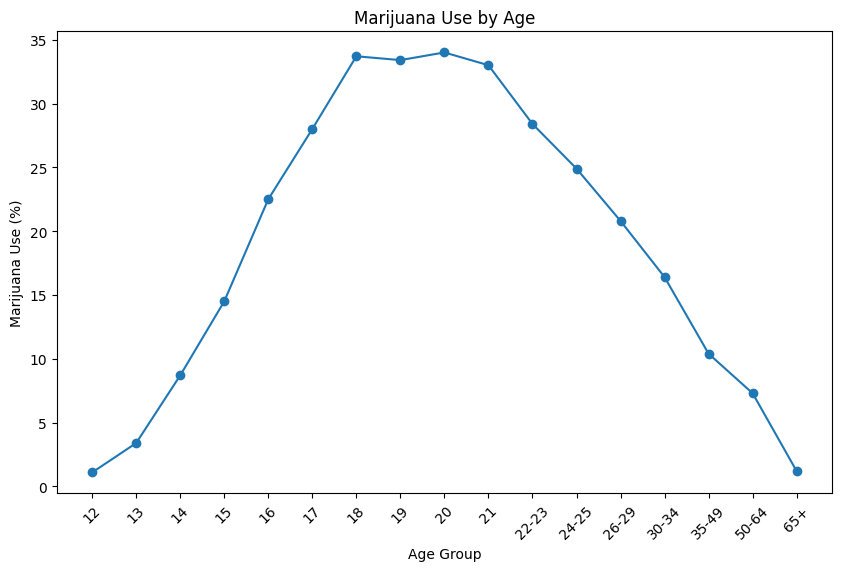

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(df["age"], df["marijuana_use"], marker="o")
plt.xlabel("Age Group")
plt.ylabel("Marijuana Use (%)")
plt.title("Marijuana Use by Age")
plt.xticks(rotation=45)
plt.show()


10.Histogram of Marijuana Use Question: What does the distribution of marijuana use look like?


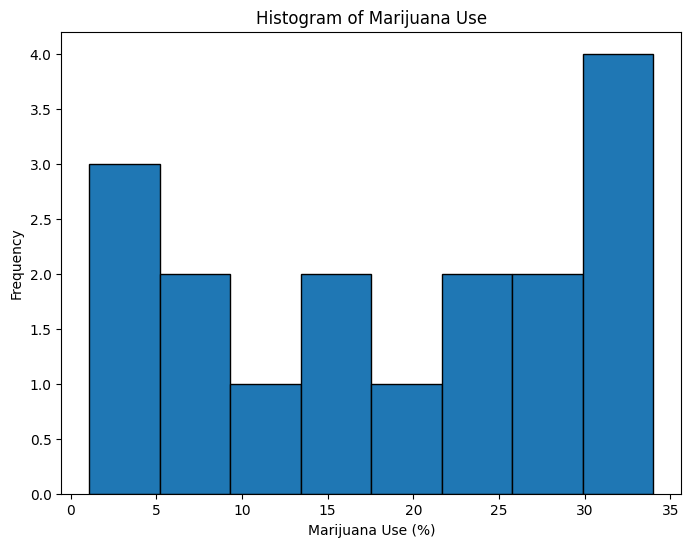

In [11]:
plt.figure(figsize=(8, 6))
plt.hist(df["marijuana_use"], bins=8, edgecolor="black")
plt.xlabel("Marijuana Use (%)")
plt.ylabel("Frequency")
plt.title("Histogram of Marijuana Use")
plt.show()


11.Alcohol Use by Age Question: How does alcohol use change by age?


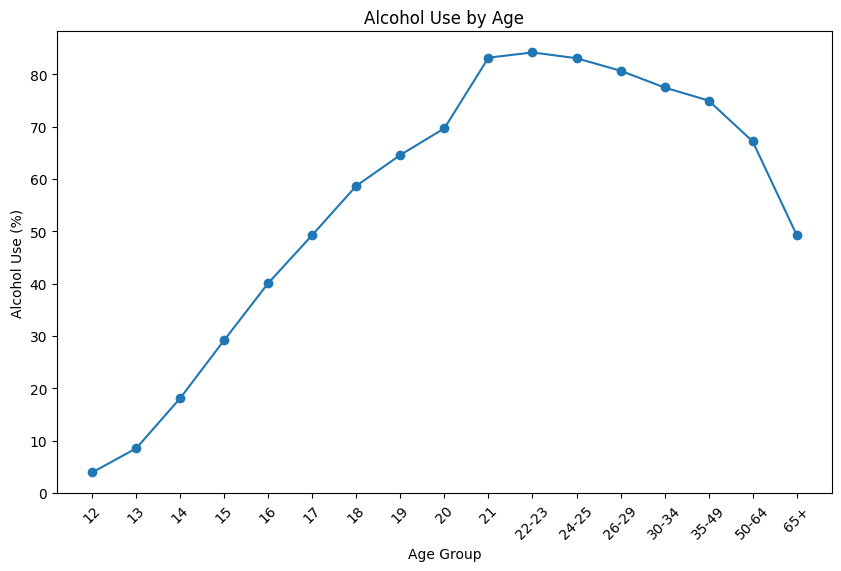

In [12]:

plt.figure(figsize=(10, 6))
plt.plot(df["age"], df["alcohol_use"], marker="o")
plt.xlabel("Age Group")
plt.ylabel("Alcohol Use (%)")
plt.title("Alcohol Use by Age")
plt.xticks(rotation=45)
plt.show()


12.Compare Alcohol and Marijuana Question: How do alcohol and marijuana use compare?


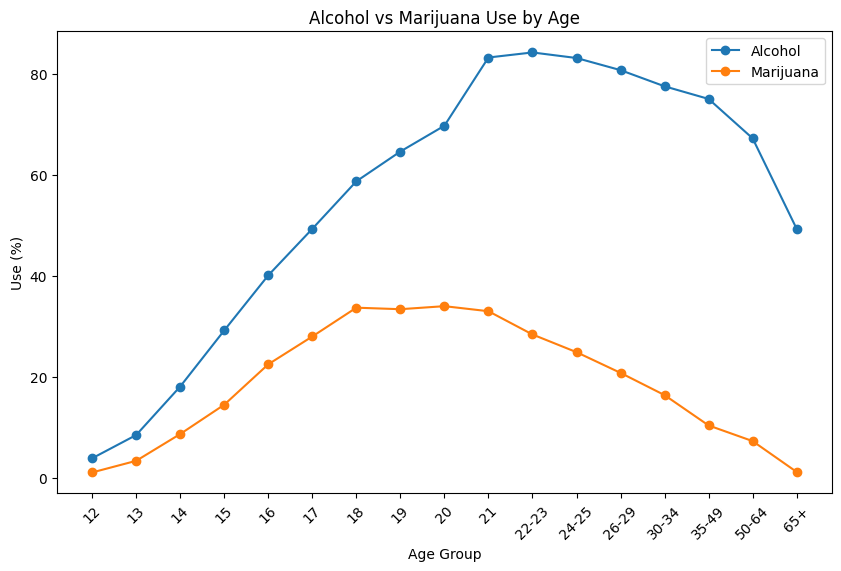

In [13]:


plt.figure(figsize=(10, 6))
plt.plot(df["age"], df["alcohol_use"], marker="o", label="Alcohol")
plt.plot(df["age"], df["marijuana_use"], marker="o", label="Marijuana")
plt.legend()
plt.xlabel("Age Group")
plt.ylabel("Use (%)")
plt.title("Alcohol vs Marijuana Use by Age")
plt.xticks(rotation=45)
plt.show()


13 Average Marijuana Use by Age Group Question: What is the average marijuana use for each age group?


In [14]:

group_means = df.groupby("age_group")["marijuana_use"].mean()
group_means


age_group
Older Adults (35+)       8.850000
Unknown                  1.200000
Young Adults (18-34)    28.075000
Youth (12-17)           13.033333
Name: marijuana_use, dtype: float64

14.Bar Chart

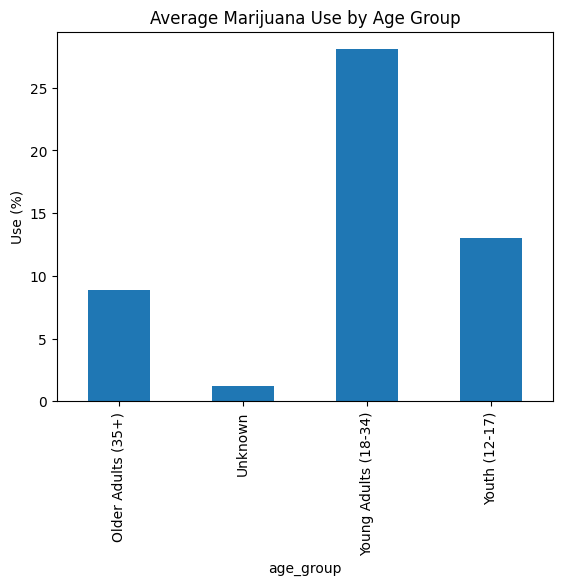

In [15]:

group_means.plot(kind="bar")
plt.title("Average Marijuana Use by Age Group")
plt.ylabel("Use (%)")
plt.show()


15.Highest Substance Use

In [16]:
use_columns = [col for col in df.columns if col.endswith("_use")]
average_use = df[use_columns].mean().sort_values(ascending=False)
average_use


alcohol_use          55.429412
marijuana_use        18.923529
pain_releiver_use     6.270588
hallucinogen_use      3.394118
tranquilizer_use      2.805882
cocaine_use           2.176471
stimulant_use         1.917647
inhalant_use          1.388235
oxycontin_use         0.935294
meth_use              0.382353
heroin_use            0.352941
crack_use             0.294118
sedative_use          0.282353
dtype: float64

16.Histogram of Alcohol Use

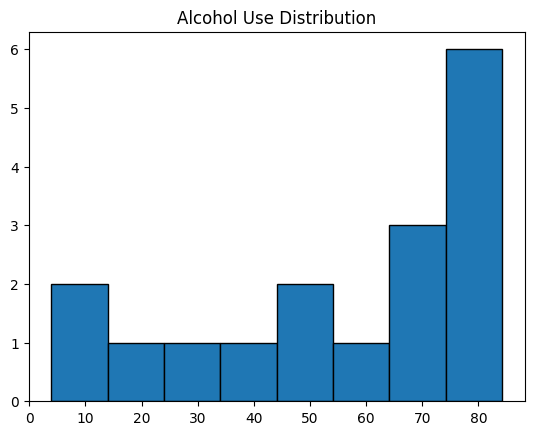

In [17]:
plt.hist(df["alcohol_use"], bins=8, edgecolor="black")
plt.title("Alcohol Use Distribution")
plt.show()


17: Bootstrap Analysis

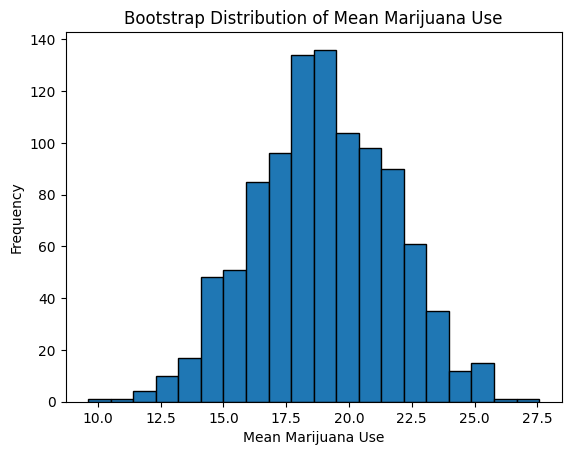

95% Confidence Interval: 13.598382352941178 24.25029411764705


In [18]:
# Step 17: Bootstrap Analysis for Marijuana Use

bootstrap_means = []

for i in range(1000):
    sample = df["marijuana_use"].dropna().sample(frac=1, replace=True)
    bootstrap_means.append(sample.mean())

# Plot histogram of bootstrap means
plt.hist(bootstrap_means, bins=20, edgecolor="black")
plt.title("Bootstrap Distribution of Mean Marijuana Use")
plt.xlabel("Mean Marijuana Use")
plt.ylabel("Frequency")
plt.show()

# Confidence interval
lower = np.percentile(bootstrap_means, 2.5)
upper = np.percentile(bootstrap_means, 97.5)

print("95% Confidence Interval:", lower, upper)

17.Conclusion

Answer:
The EDA shows that substance use varies by age group. Marijuana use increases from youth to young
adulthood and then changes among older adults. Alcohol use is generally higher than marijuana use.
These results suggest that age plays an important role in substance use behavior.
As age increases → marijuana use increases
As age increases → alcohol use increases

 When one increases and the other also increases = positive relationship
18. Limitation
Answer:
This dataset does not include geographic or time variables such as city, county, state, or year.
Therefore, it cannot be used for Twin Cities or location-based analysis.
